In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)
warnings = __import__('warnings')
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/PJME_hourly.csv')
df.columns = ['datetime', 'energy_mw']
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')
df = df.sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Shape: (145366, 1)
Date range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00


,energy_mw
datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [2]:

print(f"Duplicate timestamps: {df.index.duplicated().sum()}")

full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_hours = full_range.difference(df.index)
print(f"Missing hours: {len(missing_hours)}")

if len(missing_hours) > 0:
    print("\nSample missing timestamps:")
    print(missing_hours[:10])

Duplicate timestamps: 4
Missing hours: 30

Sample missing timestamps:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[us]', freq=None)


In [5]:
df = df[~df.index.duplicated(keep='first')]
df = df.reindex(full_range)
df.index.name = 'datetime'
df.columns = ['energy_mw']

df['energy_mw'] = df['energy_mw'].interpolate(method='linear')

print(f"Missing after interpolation: {df.isnull().sum().sum()}")
print(f"New shape: {df.shape}")

Missing after interpolation: 0
New shape: (145392, 1)


In [6]:
Q1 = df['energy_mw'].quantile(0.25)
Q3 = df['energy_mw'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_before = ((df['energy_mw'] < lower) | (df['energy_mw'] > upper)).sum()

df['energy_mw'] = df['energy_mw'].clip(lower=lower, upper=upper)

print(f"Outliers capped: {outliers_before}")
print(f"Bounds: [{lower:.0f}, {upper:.0f}]")

Outliers capped: 3460
Bounds: [15457, 47761]


In [7]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['quarter'] = df.index.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

print(f"Features: {df.columns.tolist()}")
print(f"Shape: {df.shape}")
df.head()

Features: ['energy_mw', 'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos']
Shape: (145392, 15)


,energy_mw,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos
datetime,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,1,1,1,0,0.258819,0.965926,0.5,0.866025,0.781831,0.62349
2002-01-01 02:00:00,29265.0,2,1,1,2002,1,1,1,0,0.500000,0.866025,0.5,0.866025,0.781831,0.62349
2002-01-01 03:00:00,28357.0,3,1,1,2002,1,1,1,0,0.707107,0.707107,0.5,0.866025,0.781831,0.62349
2002-01-01 04:00:00,27899.0,4,1,1,2002,1,1,1,0,0.866025,0.500000,0.5,0.866025,0.781831,0.62349
2002-01-01 05:00:00,28057.0,5,1,1,2002,1,1,1,0,0.965926,0.258819,0.5,0.866025,0.781831,0.62349


In [8]:
df['lag_24h'] = df['energy_mw'].shift(24)      
df['lag_168h'] = df['energy_mw'].shift(168)    
df['rolling_24h_mean'] = df['energy_mw'].rolling(24).mean()
df['rolling_7d_mean'] = df['energy_mw'].rolling(168).mean()

df_features = df.dropna().copy()

print(f"Shape after lag features: {df_features.shape}")
df_features.head()

Shape after lag features: (145224, 19)


,energy_mw,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,lag_24h,lag_168h,rolling_24h_mean,rolling_7d_mean
datetime,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,2002,8,2,1,0,0.258819,0.965926,0.5,0.866025,0.781831,0.62349,26862.0,30393.0,33560.208333,32513.869048
2002-01-08 02:00:00,28670.0,2,1,1,2002,8,2,1,0,0.500000,0.866025,0.5,0.866025,0.781831,0.62349,25976.0,29265.0,33672.458333,32510.327381
2002-01-08 03:00:00,28375.0,3,1,1,2002,8,2,1,0,0.707107,0.707107,0.5,0.866025,0.781831,0.62349,25641.0,28357.0,33786.375000,32510.434524
2002-01-08 04:00:00,28542.0,4,1,1,2002,8,2,1,0,0.866025,0.500000,0.5,0.866025,0.781831,0.62349,25666.0,27899.0,33906.208333,32514.261905
2002-01-08 05:00:00,29261.0,5,1,1,2002,8,2,1,0,0.965926,0.258819,0.5,0.866025,0.781831,0.62349,26328.0,28057.0,34028.416667,32521.428571


Train: 2002-01-08 01:00:00 → 2017-12-31 23:00:00 (140087 rows)
Test:  2018-01-01 00:00:00 → 2018-08-03 00:00:00 (5137 rows)
Split ratio: 96.5% / 3.5%


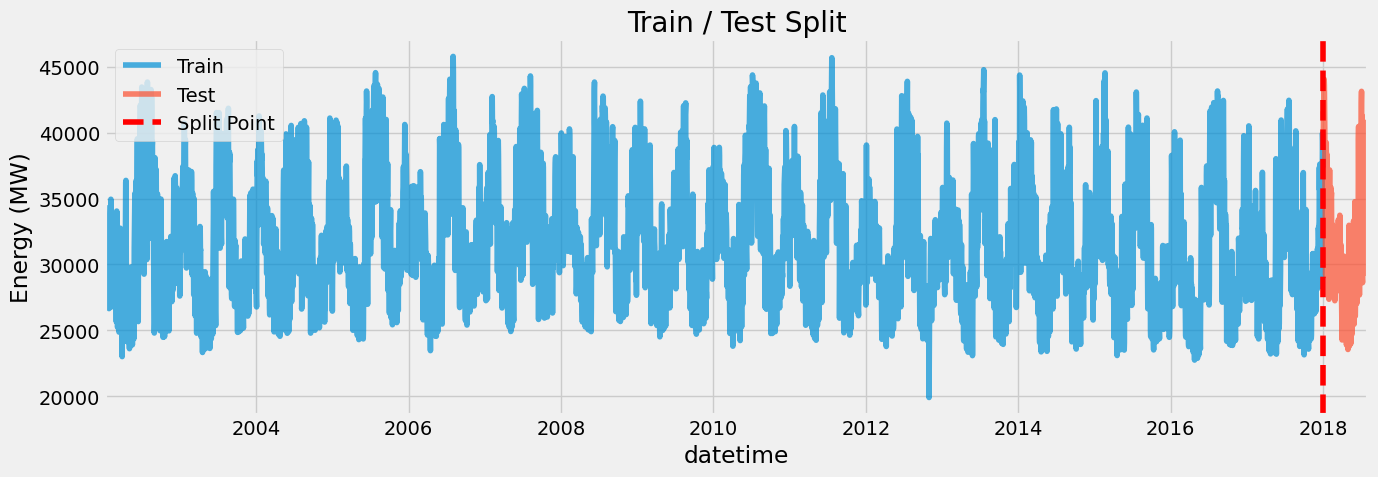

In [9]:
split_date = '2018-01-01'

train = df_features[df_features.index < split_date]
test = df_features[df_features.index >= split_date]

print(f"Train: {train.index.min()} → {train.index.max()} ({len(train)} rows)")
print(f"Test:  {test.index.min()} → {test.index.max()} ({len(test)} rows)")
print(f"Split ratio: {len(train)/len(df_features)*100:.1f}% / {len(test)/len(df_features)*100:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
train['energy_mw'].resample('D').mean().plot(ax=ax, label='Train', alpha=0.7)
test['energy_mw'].resample('D').mean().plot(ax=ax, label='Test', alpha=0.7)
ax.axvline(pd.Timestamp(split_date), color='red', linestyle='--', label='Split Point')
ax.set_title('Train / Test Split')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
df_features.to_csv('../data/pjme_preprocessed.csv')
train.to_csv('../data/train.csv')
test.to_csv('../data/test.csv')

df[['energy_mw']].to_csv('../data/pjme_clean.csv')

print("Saved:")
print("  → data/pjme_preprocessed.csv (full featured)")
print("  → data/train.csv")
print("  → data/test.csv")
print("  → data/pjme_clean.csv (for ARIMA/Prophet)")

Saved:
  → data/pjme_preprocessed.csv (full featured)
  → data/train.csv
  → data/test.csv
  → data/pjme_clean.csv (for ARIMA/Prophet)
